In [1]:
from pyhermes.base.convols import Convols
from pyhermes.io import WindowFunc
import matplotlib.pyplot as plt
import numpy as np

18:14:16 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
18:14:16 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.fin.path' from './data.bin' to './quijote10000.bin'

18:14:16 - INFO - pyhermes.pipeline.pipeline:Convols - The task will run on 1 MPI ranks with 1 threads per rank
18:14:16 - INFO - pyhermes.io.funcs:read_particle_data - Selected input particle format: generic_pos
18:14:16 - INFO - pyhermes.io.funcs:read_generic_pos_only - Reading paricle data from ---> ./quijote10000.bin <---
18:14:16 - INFO - pyhermes.pipeline.pipeline:Convols - Single process mode
18:14:18 - INFO - pyhermes.pipeline.pipeline:Convols - The time for scaling function: 1.1573 sec

18:14:18 - INFO - pyhermes.pipeline.pipeline:Convols - The time for task: 1.2160 sec
18:14:18 - INFO - pyhermes.pipeline.pipeline:Convols - Bye.




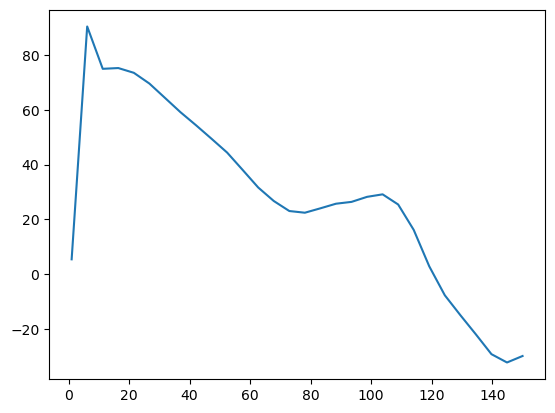

In [2]:
# Step 1: build the multiresolution coefficient field from particle positions
task_params = {'Convols': {'fin': {'path': './quijote10000.bin'}}}
D = Convols(task_params).run()

# Step 2: construct the fluctuation field delta = D - R
R = 1 / D.V # uniform random field in the same normalized convention
RR = R ** 2 # <RR>, used to normalize the 2PCF estimator
deltaD = D - R # fluctuation field, i.e. the overdensity-like field

# Step 3: smooth the fluctuation field with a spherical window
win_params = {"type": "sphere", "len_args": {"R": 5}} # spherical top-hat window of radius 5
win_filter = WindowFunc(win_params, D.convols_info)
deltaD_w = deltaD @ win_filter # smoothed fluctuation field

# Step 4: measure xi(r) by shell convolution + spatial averaging
# DD(r) = <n(x)n(x+r)>; n(x+r) = n_r(x) = n(x) @ W_shell(r)
# \xi = (D-R)(D-R)/RR
r_arr = np.linspace(1, 150, 30)
xi_arr = np.zeros_like(r_arr)
for i, r in enumerate(r_arr):
    win_params = {"type": "shell", "len_args": {"R": r}}
    win_shell = WindowFunc(win_params, D.convols_info)
    deltaDD_w = deltaD_w @ win_shell * deltaD_w # shell-convolved field multiplied by the original field
    xi_arr[i] = deltaDD_w.as_array().mean() / RR # spatial mean gives xi(r) after normalization by RR

plt.plot(r_arr, xi_arr * r_arr**2)
plt.show()

18:16:23 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
18:16:23 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.fin.path' from './data.bin' to './quijote10000.bin'

18:16:23 - INFO - pyhermes.pipeline.pipeline:Convols - The task will run on 1 MPI ranks with 1 threads per rank
18:16:23 - INFO - pyhermes.io.funcs:read_particle_data - Selected input particle format: generic_pos
18:16:23 - INFO - pyhermes.io.funcs:read_generic_pos_only - Reading paricle data from ---> ./quijote10000.bin <---
18:16:23 - INFO - pyhermes.pipeline.pipeline:Convols - Single process mode
18:16:24 - INFO - pyhermes.pipeline.pipeline:Convols - The time for scaling function: 0.1454 sec

18:16:24 - INFO - pyhermes.pipeline.pipeline:Convols - The time for task: 0.2034 sec
18:16:24 - INFO - pyhermes.pipeline.pipeline:Convols - Bye.




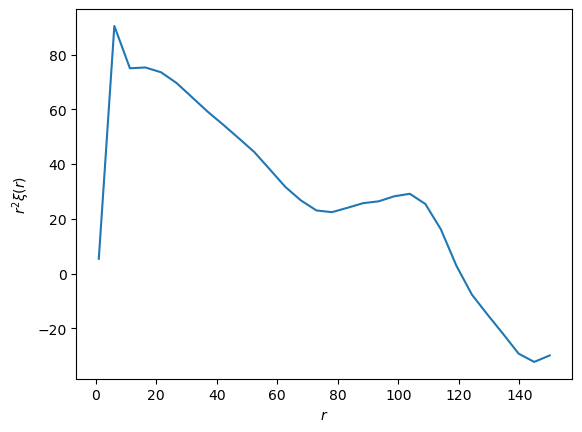

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from pyhermes.base.convols import Convols
from pyhermes.io import WindowFunc

# Step 1: build the multiresolution coefficient field from particle positions
task_params = {'Convols': {'fin': {'path': './quijote10000.bin'}}}
D = Convols(task_params).run()

# Step 2: construct the fluctuation field delta = D - R
R = 1 / D.V          # uniform random field in the same normalized convention
RR = R ** 2          # <RR>, used to normalize the 2PCF estimator
deltaD = D - R       # fluctuation field

# Step 3: smooth the fluctuation field with a spherical window
win_params = {"type": "sphere", "len_args": {"R": 5}}
win_filter = WindowFunc(win_params, D.convols_info)
deltaD_w = deltaD @ win_filter

# Step 4: measure xi(r) by shell convolution + spatial averaging
# DD(r) = <n(x)n(x+r)>; n(x+r) = n_r(x) = n(x) @ W_shell(r)
# xi = (D-R)(D-R)/RR
r_arr = np.linspace(1, 150, 30)
xi_arr = np.zeros_like(r_arr)

for i, r in enumerate(r_arr):
    win_params = {"type": "shell", "len_args": {"R": r}}
    win_shell = WindowFunc(win_params, D.convols_info)

    # n(x+r) is obtained by convolving the field with a shell window of radius r
    deltaDD_w = deltaD_w @ win_shell * deltaD_w

    # spatial mean + RR normalization gives xi(r)
    xi_arr[i] = deltaDD_w.as_array().mean() / RR

plt.plot(r_arr, xi_arr * r_arr**2)
plt.xlabel(r"$r$")
plt.ylabel(r"$r^2 \xi(r)$")
plt.show()